In [54]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view #for easy minima without using for loops
from math import *
# from collections import deque
import matplotlib.pyplot as plt
import scipy as sp
import sys
np.set_printoptions(threshold=sys.maxsize)


## Homework 2: Dodge FI2026
Instead of previous hyper-efficient code (which took too much time to optimize), put less effort into optimization, just make it work

O Earth FI2026
q [au] 9.78969676e-01 0.74161536
e [ ] 1.83889630e-02 0.19293483
i [rad] 7.55697209e-05 0.05877868
ω [rad] 5.34322623 2.22509624
Ω [rad] 2.63906227 3.55784498
M [rad] 1.88972281 3.64624167

In [2]:
# constants taken from Prof. Eggl's repository, and verified by AE402 code
mu_sun   = 1.32712440018e11   # km^3/s^2
mu_earth = 398600.4418        # km^3/s^2
R_earth  = 6378.137           # km
deg2rad  = np.pi/180.0
au2km = 149597870.7

In [3]:
print(f"{R_earth/au2km:.6f}")

0.000043


In [4]:
# Earth keplerian elements wrt sun
# q (periapsis), e, i, argpe, raan, Mean Anomaly (rad)
earth_kep_hel = [9.78969676e-01, 1.83889630e-02, 7.55697209e-05, 5.34322623, 2.63906227, 1.88972281]
fi2026_kep_hel = [0.74161536, 0.19293483, 0.05877868, 2.22509624, 3.55784498, 3.64624167]

# make it clearer to myself what I'm putting into each function
q1 = earth_kep_hel[0] *au2km
e1 = earth_kep_hel[1]
i1 = earth_kep_hel[2]
argpe1 = earth_kep_hel[3]
raan1 = earth_kep_hel[4]
M1 = earth_kep_hel[5]
a1 = q1/(1-e1)

q2 = fi2026_kep_hel[0] *au2km
e2 = fi2026_kep_hel[1]
i2 = fi2026_kep_hel[2]
argpe2 = fi2026_kep_hel[3]
raan2 = fi2026_kep_hel[4]
M2 = fi2026_kep_hel[5]
a2 = q2/(1-e2)

### PRoblem 1: Time to impact

In [5]:
# Let's not use any of the old code, I don't trust the MOID transformations to be right
# Need to get cartesian coords -> need cartesian timestepping equations corresponding to orb elements
# Newton's method for E
# Looks like I need Curtis to propagate in universal variables (Example 3.6, section 3.7, page 139)
# I want to step both Earth and FI2026's trajecs to where their minimum distance is below Earth's radius, and then take that time.

#for part 2, don't forget to calculate if FI2026 is in hill sphere

# two ways of doing this: either you find M(t) and continuously convert into cartesian, or you do Curtis propagation
# Either way requires a cartesian solver
# Simpler to find M(t) = sqrt(mu/a^3)*t, where t is time since periapsis
# t0 can be found, then at every timestep t, calculate r and find distance between.

# algorithm 3.3 (Curtis)
# note that r0 and v_r0 do NOT have to be at periapsis, they can be at any specified true anomaly
# alpha = 1/a, reciprocal of SMA

def solve_kep(M,e,tol = 1e-12,maxiter=200):
    """
    Updated from AE402 with reference to Prof. Eggl's code (faster loop function)
    M = E-e*sin(E) for elliptic orbits
    """
    E = M if e<0.8 else pi
    # print("Newton's Method:")
    for _ in range(maxiter):
    # for i in range(maxiter):
        g = E-e*sin(E) - M
        dg_dE = 1-e*cos(E) #derivative dg over dE
        dE = g/dg_dE
        E -= dE #condensed for efficiency
        # print(dE)
        if abs(dE) < tol: #little updates to the rate instead of the value of M
            # print("iter=",i) #debugging this stupid fxn
            break
        
        # # Original logic for this function:
        # E -= g/dg_dE #not at the same time as the dE limiter
        # if abs(g) > tol: #tol should be 1e-10 as that worked in 402
        #     break
    return E

def R3(theta):
    """Rotate around Z axis, now with rotating in correct direction this time"""
    c,s = np.cos(theta),np.sin(theta)
    return np.array([[ c, -s, 0],
                     [ s,  c, 0],
                     [ 0,  0, 1]])

def R1(theta):
    """Rotate around X axis, now with rotating in correct direction this time"""
    c,s = np.cos(theta),np.sin(theta)
    return np.array([[ 1, 0, 0],
                     [ 0,  c, -s],
                     [ 0,  s,  c]])

def keplerian_to_cartesian(a,e,i,argpe,raan,M,mu):
    """
    Convert from keplerian to cartesian, elliptical only
    Inputs:
    - p: Periapsis
    - a: SMA
    - e: eccentricity
    - i: inclination
    - argpe: argument of periapsis
    - raan: right ascension
    - M: mean anomaly
    - mu: grav parameter of orbiting body
    """
    E = solve_kep(M,e) #eccentric anomaly
    r = a*(1-e*cos(E)) #current radius from orbiting body
    
    #tan(f/2) = sqrt((1+e)/(1-e))*tan(E/2)
    f = 2*atan2(sqrt(1+e)*sin(E/2), sqrt(1-e)*cos(E/2)) #true anomaly
    # print(f"Periapsis check: {r*(1+e*cos(f)):.4e}, actual p: {p:.4e}, Radius: {p/(1+e*cos(f)):.4e}, Actual radius: {r:.4e}") #check for periapsis
    p = a*(1 - e**2) # p is semilatus rectum, NOT periapsis!!!
    r_pqw = np.array([r*cos(f), r*sin(f), 0])
    v_pqw = sqrt(mu/p)*np.array([-sin(f), e+cos(f), 0])
    # h2_div_mu = a*(1-e**2) #Reverse the SMA equation
    # r = h2_div_mu/(1+e*cos(theta))
    Q = R3(raan) @ R1(i) @ R3(argpe)
    r_vec = Q@r_pqw
    v_vec = Q@v_pqw
    return r_vec,v_vec

Brute force: Generate M from t, step t to get impact location

In [6]:
t0_1 = M1/sqrt(mu_sun/a1**3) #time at initial M1
t0_2 = M2/sqrt(mu_sun/a2**3)
print(t0_1,t0_2)
print(t0_1/86400,t0_2/86400) #Better, but still big
print(sqrt(mu_sun/a1**3))
h1 = sqrt(a1*mu_sun*(1-e1**2))
# print(a1)
print(h1)
print(t0_1,M1/ ((mu_sun**2)/(h1**3)* ( (1-e1**2)**(3/2) ) ) ) #should be equal!!!!

9453118.811677149 16131803.285499875
109.4110973573744 186.71068617476706
1.9990469258311695e-07
4448975199.361868
9453118.811677149 9453118.811677145


In [ ]:
keplerian_to_cartesian(a1,e1,i1,argpe1,raan1,M1,mu_sun)

(array([-1.33006596e+08, -6.95661586e+07,  9.44828356e+03]),
 array([ 1.32810307e+01, -2.65029329e+01,  1.27180431e-03]))

In [8]:
# t0_1 = M1/sqrt(mu_sun/a1**3) #time at initial M1
# t0_2 = M2/sqrt(mu_sun/a2**3)
# print(t0_1,t0_2) #seems suspiciously low... maybe we're at periapsis??

# dt = 1.0 #day
# r0_1, v0_1 = keplerian_to_cartesian(q1,a1,e1,i1,argpe1,raan1,M1,mu_sun)
# r0_2, v0_2 = keplerian_to_cartesian(q2,a2,e2,i2,argpe2,raan2,M2,mu_sun)

def minima(D_sq): # I lied about reusing code. Minima function is needed to filter the huge amount of data
    """
    Strategy:
    1) Append 0th element to end of D_sq (for wraparound purposes)
    2) Sliding window view to create giant array of n x 3
    3) Find minima
    4) Knowing center column is either [1: (n+1)] in np.append or D_sq itself in np.pad,
    subtract D_sq from that and find zeros. Indices that are 0 are local minima.
    5) Return indices for easy math
    """

    D_sq_wrap = np.pad(D_sq,(1,1),'wrap')
    q = sliding_window_view(D_sq_wrap,3) # Produces n-1 size array, slice first element
    # print(np.min(q,axis=1)-D_sq)
    return np.argwhere((np.min(q,axis=1)-D_sq) == 0 ).T[0] #Returns indices, needed to find L and nu

def time_to_moid(a1,e1,i1,argpe1,raan1,M1, a2,e2,i2,argpe2,raan2,M2, dt=0.01,dt_refine=1e-3):
    t0_1 = M1/sqrt(mu_sun/a1**3) #time at initial M1
    t0_2 = M2/sqrt(mu_sun/a2**3)
    t1 = t0_1 # Periapsis times are different, start at different times (same epoch)
    t2 = t0_2 
    # r0_1, v0_1 = keplerian_to_cartesian(q1,a1,e1,i1,argpe1,raan1,M1,mu_sun)
    # r0_2, v0_2 = keplerian_to_cartesian(q2,a2,e2,i2,argpe2,raan2,M2,mu_sun)
    dist = []
    deltat = []
    for i in range(int(365/dt)): # look ahead a year in advance
        M1_i = sqrt(mu_sun/a1**3)*t1 #Different M for different orbit
        M2_i = sqrt(mu_sun/a2**3)*t2
        r1_i, _ = keplerian_to_cartesian(a1,e1,i1,argpe1,raan1,M1_i,mu_sun)
        r2_i, _ = keplerian_to_cartesian(a2,e2,i2,argpe2,raan2,M2_i,mu_sun)
        # print(np.linalg.norm(r2_i-r1_i))
        dist.append(np.linalg.norm(r2_i-r1_i))
        deltat.append(dt*86400*i)
        t1 += dt*86400 #dt is in days
        t2 += dt*86400
    min_dist_i = minima(dist)
    min_dist = np.array(dist)[minima(dist)]
    # min_dist_refine_refined_i = []
    min_dist_refine_refined = []
    deltat_refine_refined = []
    # for index in min_dist_i:
    #     t1 = t0_1 + deltat[index-2] #go back few days to check for local minima
    #     t2 = t0_2 + deltat[index-2]
    #     dist_refine = []
    #     # deltat_refine = []
    #     for j in range(int((10*dt)/dt_refine)): # look ahead till other side of trough
    #         M1_i = sqrt(mu_sun/a1**3)*t1 #Different M for different orbit
    #         M2_i = sqrt(mu_sun/a2**3)*t2
    #         r1_i, _ = keplerian_to_cartesian(q1,a1,e1,i1,argpe1,raan1,M1_i,mu_sun)
    #         r2_i, _ = keplerian_to_cartesian(q2,a2,e2,i2,argpe2,raan2,M2_i,mu_sun)
    #         # print(np.linalg.norm(r2_i-r1_i))
    #         dist_refine.append(np.linalg.norm(r2_i-r1_i))
    #         # deltat_refine.append(dt_refine*86400*j)
    #         t1 += dt_refine*86400 #dt is in days
    #         t2 += dt_refine*86400
    #     min_dist_refine_i = minima(dist_refine)
    #     min_dist_refine = np.array(dist_refine)[min_dist_refine_i]
    #     min_index = np.argmin(min_dist_refine)
    #     # min_dist_refine_refined_i.append(min_index)
    #     min_dist_refine_refined.append(min_dist_refine[min_index])
    #     deltat_refine_refined.append(deltat[index-2]+dt_refine*86400*min_index)
    return dist, min_dist_i, min_dist, np.min(np.array(dist)[minima(dist)]), min_dist_refine_refined, deltat_refine_refined

fi, fee, foe, fum, min_dist, deltat = time_to_moid(a1,e1,i1,argpe1,raan1,M1, a2,e2,i2,argpe2,raan2,M2)
print(fee)
print(foe)
print(np.argmin(foe))
print(fum)
print(foe[np.argmin(foe)])
print(np.array(fi[35990:36010])/au2km)

[14770 36000]
[3.85422419e+07 8.66463987e-01]
1
0.8664639869570651
0.8664639869570651
[3.40397854e-04 3.06358155e-04 2.72318470e-04 2.38278797e-04
 2.04239135e-04 1.70199481e-04 1.36159836e-04 1.02120196e-04
 6.80805601e-05 3.40409278e-05 5.79195401e-09 3.40383351e-05
 6.80779674e-05 1.02117603e-04 1.36157243e-04 1.70196889e-04
 2.04236542e-04 2.38276205e-04 2.72315878e-04 3.06355563e-04]


In [9]:
print(f"FI2026 will pass by the Earth by {np.min(foe):.3f} km, less than the radius of the Earth = {R_earth:.1f} km. \nThis means it will hit the earth in {fee[np.argmin(foe)]/100} days = {fee[np.argmin(foe)]/100*86400} seconds")

FI2026 will pass by the Earth by 0.866 km, less than the radius of the Earth = 6378.1 km. 
This means it will hit the earth in 360.0 days = 31104000.0 seconds


In [10]:
%timeit keplerian_to_cartesian(a1,e1,i1,argpe1,raan1,M1,mu_sun)
# Result proves Python is fast enough to brute force run multiple iterations in a timely manner

13.3 µs ± 644 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Problem 2: B-plane

In [11]:
# Looking at Prof. Eggl's code, first need to find when it enters the hill sphere
# Hill sphere: rh/a = (mu/3)^(1/3)
R_hill = a1*((mu_earth/mu_sun)/3)**(1/3)# Earth-sun system
R_hill # ~= 1.5e6 km
print(R_hill)

# Find when FI2026 enters hill sphere
dist_coarse = np.array(fi) # Distances between Earth and FI2026 from coarse timestepping (dt=0.01)
h_index = np.argwhere(dist_coarse > R_hill).T[0]
h_index = np.where(h_index < 36000)[0][-1] #357.07 days before entry into hill sphere
print(h_index/100)
h_day = h_index/100
# h_index

def time_to_SOI(a1,e1,i1,argpe1,raan1,M1, a2,e2,i2,argpe2,raan2,M2, start_search_day, R_hillsphere, dt=0.1, maxiter=300000):
    """
    Finds position and velocity at first entry into sphere of influence
    Note dt is now in SECONDS instead of days.
    start_search_day is still in days, accepts decimal days
    """
    t0_1 = M1/sqrt(mu_sun/a1**3) #time at initial M1
    t0_2 = M2/sqrt(mu_sun/a2**3)
    t1 = t0_1 + start_search_day*86400 # Periapsis times are different, start at different times (same epoch)
    t2 = t0_2 + start_search_day*86400
    # r0_1, v0_1 = keplerian_to_cartesian(q1,a1,e1,i1,argpe1,raan1,M1,mu_sun)
    # r0_2, v0_2 = keplerian_to_cartesian(q2,a2,e2,i2,argpe2,raan2,M2,mu_sun)
    for i in range(maxiter): # same arrangement as kepler solver
        M1_i = sqrt(mu_sun/a1**3)*t1 #Different M for different orbit
        M2_i = sqrt(mu_sun/a2**3)*t2
        r1_i, v1_i = keplerian_to_cartesian(a1,e1,i1,argpe1,raan1,M1_i,mu_sun) # Earth
        r2_i, v2_i = keplerian_to_cartesian(a2,e2,i2,argpe2,raan2,M2_i,mu_sun) # FI2026
        # print(np.linalg.norm(r2_i-r1_i))
        R2_1 = np.linalg.norm(r2_i-r1_i) #distance between r2 and r1, needs to be below hill sphere to switch into heliocentric
        # deltat.append(dt*86400*i)
        t1 += dt #dt is in SECONDS now!!!
        t2 += dt
        # print(dt*i, R2_1)
        # if i==0:
        #     break
        if abs(R2_1) < R_hillsphere: #little updates to the rate instead of the value of M
            break
    return r1_i, v1_i, r2_i, v2_i, dt*i



1492531.5298184592
357.07


In [39]:
# Opik plane time!!! (referenced from Prof. Eggl's code)

def bplane(rE,vE,rA,vA):
    """Outputs needed components for B-plane state"""
    rho = rA-rE
    u = vA-vE
    rho_n = np.linalg.norm(rho)
    u_n = np.linalg.norm(u)

    energy = 0.5*u_n**2 - mu_earth/rho_n
    v_inf  = np.sqrt(2*energy)

    h_vec  = np.cross(rho, u)
    h      = np.linalg.norm(h_vec)

    # Earth-centered hyperbola eccentricity vector
    e_h = np.cross(u, h_vec)/mu_earth - rho/rho_n
    e   = np.linalg.norm(e_h)

    # Hyperbola perifocal triad
    p_hat = e_h / e
    h_hat = h_vec / h
    q_hat = np.cross(h_hat, p_hat)

    # asymptote true anomaly
    f_inf = np.arccos(-1.0/e)

    # Incoming asymptotic velocity in inertial coordinates
    p_val = h*h/mu_earth
    u_inf_pqw = np.sqrt(mu_earth/p_val) * np.array([np.sin(f_inf), e + np.cos(f_inf), 0.0])
    u_inf_minus = u_inf_pqw[0]*p_hat + u_inf_pqw[1]*q_hat

    #check that magnitude of asymptotic velocity = hyperbolic velocity
    print(u_inf_minus,np.linalg.norm(u_inf_minus), v_inf)
    assert np.allclose(np.linalg.norm(u_inf_minus), v_inf, rtol=0, atol=1e-8)
    s_hat = u_inf_minus / v_inf
    xi_hat = np.cross(vE,s_hat)/np.linalg.norm(vE)
    zeta_hat = np.cross(-s_hat,xi_hat)

    # Impact parameter vector (correct identity): b = (u_inf x h)/|u_inf|^2
    b_vec = np.cross(u_inf_minus, h_vec) / (v_inf**2)
    # b_vec = np.cross(s_hat,h_vec)/v_inf

    # b-plane coordinates
    xi   = np.dot(b_vec, xi_hat)
    zeta = np.dot(b_vec, zeta_hat)

    # gravitational focusing collision cross section
    b_coll = R_earth * np.sqrt(1.0 + 2.0*mu_earth/(R_earth * v_inf**2))

    # debugging print statements
    print('rA, vA', rA,vA)
    print('rE, vE', rE,vE)
    # Earth - centered Encounter state
    print('Earth centered encounter state')
    print('rho [km]=', rho)
    print('rho_n [km]=',rho_n)
    print('u [km/s]=',u)
    print('energy=',energy)
    print('h_vec=',h_vec)
    print('eccentricity vector=', e_h)
    print('eccentricity=', e)
    print('v_inf [km/s]=', v_inf)
    print('p_hat =',p_hat)
    print('h_hat =',h_hat)
    print('q_hat =',q_hat)

    # asymptote true anomaly
    print('f_inf = ',f_inf)
    print('u_inf^- =',u_inf_minus)
    # print('s_hat=',s_hat)
    print('zeta_hat=',zeta_hat)

    # b-plane coordinates
    print('(xi, zeta) [km]=', xi, zeta)

    # gravitational focusing
    print('b_coll [km]=', b_coll)

    return b_coll, xi, zeta

def plot_bplane(b_coll,xi,zeta):
    th_space = np.linspace(0,2*np.pi,1000)
    # fig, ax = plt.subplots(figsize=(7.5, 7.0), dpi=150)
    fig = plt.figure(figsize=(7.5, 7.0), dpi=100)
    ax = fig.add_subplot(111)

    ax.plot(b_coll*np.cos(th_space),b_coll*np.sin(th_space),label="Earth + Grav Focusing (b_coll)")
    ax.plot([xi], [zeta], 'o', label=r'Encounter point $(\xi,\zeta)$')
    ax.plot(4*R_earth*np.cos(th_space), 4*R_earth*np.sin(th_space), linestyle="--", label = '4x R_earth Impact margin')

    ax.set_aspect('equal', 'box')
    ax.set_xlabel(r'$\xi$ [km]')
    ax.set_ylabel(r'$\zeta$ [km]')
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.grid(which='major', linestyle='-', linewidth='.8', color='gray')
    ax.minorticks_on()
    ax.legend(bbox_to_anchor=(1.52, 1.05))
    return fig
    # fig.savefig(title+"_hw2.png",format='png',dpi=300)
    # plt.show()

# # Earth-centered relative state
# rE = r1_h
# vE = v1_h # Earth's velocity at entry into SOI
# rho = r2_h-r1_h
# u = v2_h-v1_h
# rho_n = np.linalg.norm(rho)
# u_n = np.linalg.norm(u)

# energy = 0.5*u_n**2 - mu_earth/rho_n
# v_inf  = np.sqrt(2*energy)

# h_vec  = np.cross(rho, u)
# h      = np.linalg.norm(h_vec)

# # Earth-centered hyperbola eccentricity vector
# e_h = np.cross(u, h_vec)/mu_earth - rho/rho_n
# e   = np.linalg.norm(e_h)

# # Hyperbola perifocal triad
# p_hat = e_h / e
# h_hat = h_vec / h
# q_hat = np.cross(h_hat, p_hat)

# # asymptote true anomaly
# f_inf = np.arccos(-1.0/e)

# # Incoming asymptotic velocity in inertial coordinates
# p_val = h*h/mu_earth
# u_inf_pqw = np.sqrt(mu_earth/p_val) * np.array([np.sin(f_inf), e + np.cos(f_inf), 0.0])
# u_inf_minus = u_inf_pqw[0]*p_hat + u_inf_pqw[1]*q_hat

# #check that magnitude of asymptotic velocity = hyperbolic velocity
# assert np.allclose(np.linalg.norm(u_inf_minus), v_inf, rtol=0, atol=1e-8)

# # delta = 2*np.arcsin(1./e)
# # u_inf_plus = vecRot3D(u_inf_minus, h_hat, delta)

# # assert np.allclose(np.linalg.norm(u_inf_plus), v_inf, rtol=0, atol=1e-8)

# # r_p = h*h/mu_earth/(1+e) 
# # v_plus = vE + u_inf_plus

# # Öpik frame: eta along incoming asymptote, and (xi,zeta) spanning b-plane
# # eta_hat = u_inf_minus / v_inf
# # k_hat = np.cross(rE, vE)
# # k_hat = k_hat / np.linalg.norm(k_hat)
# # xi_hat = np.cross(k_hat, eta_hat)
# # xi_hat = xi_hat / np.linalg.norm(xi_hat)
# # zeta_hat = np.cross(eta_hat, xi_hat)
# s_hat = u_inf_minus / v_inf
# xi_hat = np.cross(vE,s_hat)/np.linalg.norm(vE)
# zeta_hat = np.cross(-s_hat,xi_hat)

# # Impact parameter vector (correct identity): b = (u_inf x h)/|u_inf|^2
# b_vec = np.cross(u_inf_minus, h_vec) / (v_inf**2)
# # b_vec = np.cross(s_hat,h_vec)/v_inf
# b = np.linalg.norm(b_vec)

# # b-plane coordinates
# xi   = np.dot(b_vec, xi_hat)
# zeta = np.dot(b_vec, zeta_hat)

# # gravitational focusing collision cross section
# b_coll = R_earth * np.sqrt(1.0 + 2.0*mu_earth/(R_earth * v_inf**2))
# # sigma_coll = np.pi * b_coll**2

#### First attempt: Plot near impact epoch
We plot close to time of impact: half a day from impact.

This makes it hit dead-on on the b-plane (closer to what others got) but should be inaccurate as it only starts accounting for Earth's gravity while deep inside the hill sphere

In [47]:
r1_h,v1_h,r2_h,v2_h, t_SOI = time_to_SOI(a1,e1,i1,argpe1,raan1,M1, a2,e2,i2,argpe2,raan2,M2, h_day,R_hill-1.2e6, dt=2.0)
print(f"FI2026 enters Earth's (SOI - 1 million km) radius at {h_day*86400 + t_SOI :.1f} seconds = {(h_day + t_SOI/86400) :.6f} days from initial epoch")
# 2.0 second precision

FI2026 enters Earth's (SOI - 1 million km) radius at 31054368.0 seconds = 359.425556 days from initial epoch


In [48]:
print(np.linalg.norm(r2_h-r1_h))

292529.06392981036


[4.03155245 3.64470136 1.574673  ] 5.658344122359296 5.65834412230816
rA, vA [-1.37840838e+08 -5.95908455e+07 -7.24717457e+04] [ 15.4762432  -23.66139256   1.6417316 ]
rE, vE [-1.37632418e+08 -5.94024149e+07  8.94354105e+03] [ 1.12766186e+01 -2.74580427e+01  1.40801425e-03]
Earth centered encounter state
rho [km]= [-208419.5366551  -188430.62668788  -81415.28671042]
rho_n [km]= 292529.06392981036
u [km/s]= [4.19962462 3.79665012 1.64032358]
energy= 16.00842910322965
h_vec= [ 18.15722431 -38.16183266  41.84150058]
eccentricity vector= [0.71303021 0.64377715 0.27774019]
eccentricity= 1.000000356347686
v_inf [km/s]= 5.65834412230816
p_hat = [0.71302996 0.64377692 0.27774009]
h_hat = [ 0.30531563 -0.64169521  0.70356921]
q_hat = [-0.6311661   0.41686753  0.65410306]
f_inf =  3.1407484408438813
u_inf^- = [4.03155245 3.64470136 1.574673  ]
zeta_hat= [-0.61156427  0.71559088 -0.0905341 ]
(xi, zeta) [km]= -7.45812740178493 -6.569789004411512
b_coll [km]= 14124.180706424191


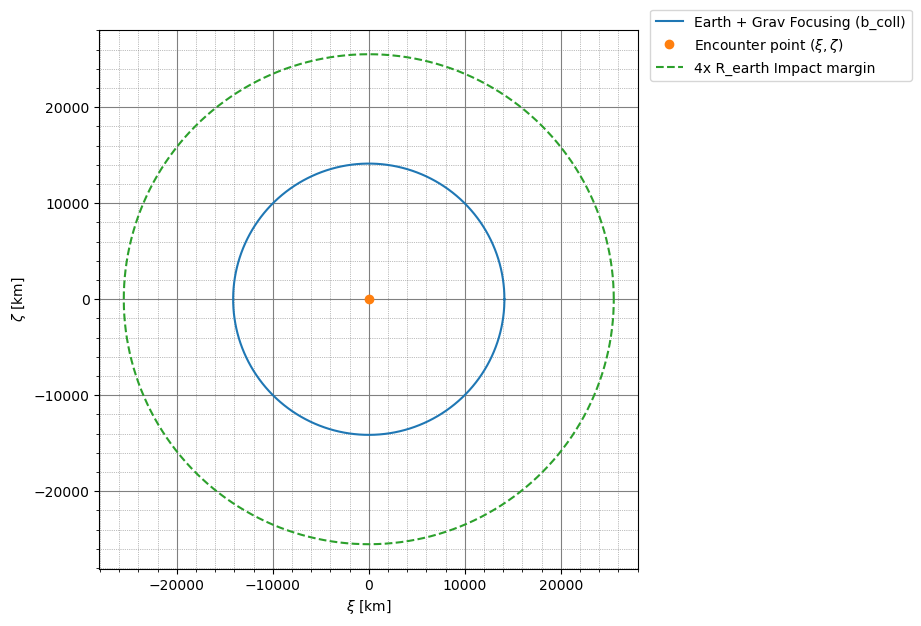

In [49]:
b_coll, xi, zeta = bplane(r1_h,v1_h, r2_h, v2_h)
plt_deadon = plot_bplane(b_coll,xi,zeta)
plt_deadon.savefig("p2_atimpact_hw2.png",format='png',dpi=300)
plt.show()

#### Second attempt: Plot at R_hill

Plot as FI2026 crosses Hill Sphere at T +357.07 days, or just under 3 days to impact. No longer hit dead on, 1000 km off

FI2026 enters Earth's (SOI - 1 million km) radius at 30850917.4 seconds = 357.070803 days from initial epoch
Distance from Earth [km]= 1492531.313
[4.17999608 3.77004752 1.62575484] 5.859070260660866 5.85907026066092
rA, vA [-1.40877585e+08 -5.47301963e+07 -4.06335209e+05] [ 14.37571258 -24.11287094   1.63984517]
rE, vE [-1.39813742e+08 -5.37691161e+07  8.64986107e+03] [ 1.01633380e+01 -2.79121454e+01  1.47860891e-03]
Earth centered encounter state
rho [km]= [-1063843.01628137  -961080.19830762  -414985.070053  ]
rho_n [km]= 1492531.312648595
u [km/s]= [4.21237459 3.79927446 1.63836656]
energy= 17.164352159680615
h_vec= [ 2040.52210514 -5107.743383    6598.20323647]
eccentricity vector= [0.79666305 0.58258424 0.20461362]
eccentricity= 1.0079400473121467
v_inf [km/s]= 5.85907026066092
p_hat = [0.79038733 0.57799493 0.20300178]
h_hat = [ 0.23754469 -0.5946112   0.76812111]
q_hat = [-0.56467724  0.5588912   0.60727278]
f_inf =  3.0159911896336626
u_inf^- = [4.17999608 3.77004752 1.6257548

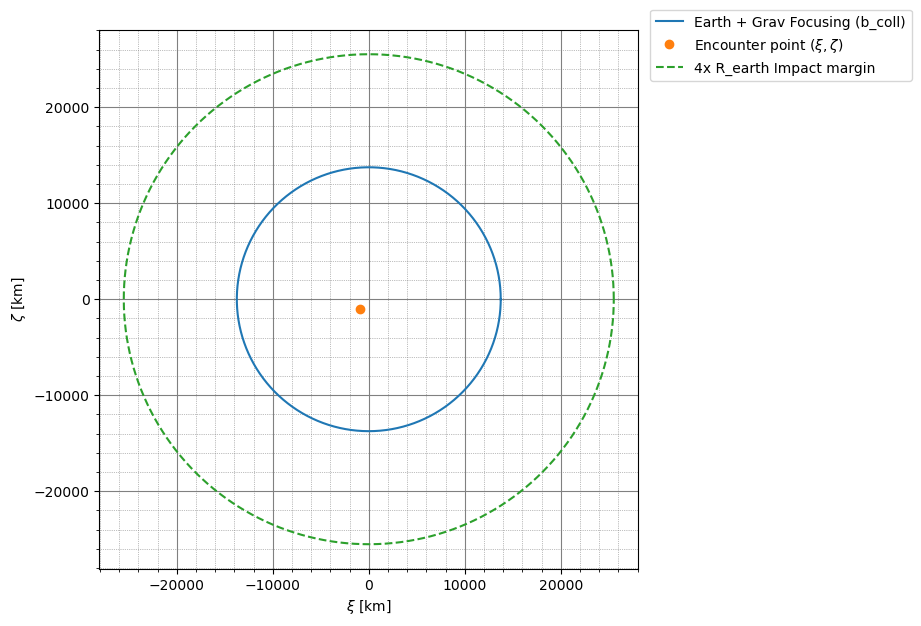

In [77]:
r1_h,v1_h,r2_h,v2_h, t_SOI = time_to_SOI(a1,e1,i1,argpe1,raan1,M1, a2,e2,i2,argpe2,raan2,M2, h_day,R_hill)
print(f"FI2026 enters Earth's (SOI - 1 million km) radius at {h_day*86400 + t_SOI :.1f} seconds = {(h_day + t_SOI/86400) :.6f} days from initial epoch")
# 0.1 second precision (69.4 seconds to SOI)
print(f"Distance from Earth [km]= {np.linalg.norm(r2_h-r1_h):.3f}")
b_coll, xi, zeta = bplane(r1_h,v1_h, r2_h, v2_h)
plt_deadon = plot_bplane(b_coll,xi,zeta)
plt_deadon.savefig("p2_athill_hw2.png",format='png',dpi=300)
plt.show()

xi, zeta being 1000 km is different from the 0.866 km miss distance previously found. Maybe accounting for Earth gravity/position?

Test code to check when Prof's Opik example initialized at. DO NOT DELETE!

Result: Approximately at edge of Hill sphere

In [ ]:
# # test code
# a1 = 9.973091572352096E-01*au2km
# e1 = 1.838896295295013E-02
# i1 = 4.329826068186278E-03*deg2rad
# w1 = 3.061443121940218E+02 *deg2rad
# O1 = 1.512071301280637E+02*deg2rad
# M1 = 1.016491301017181E+02*deg2rad

# # Apophis
# a2 = 9.190965593865476E-01*au2km
# e2 = 1.929348335924014E-01
# i2 = (3.367770080090324E+00)*deg2rad
# w2 = 1.274886235983452E+02*deg2rad
# O2 = 2.038495014776776E+02*deg2rad
# M2 = 2.484530662165266E+02*deg2rad

# q1 = a1*(1-e1)
# q2 = a2*(1-e2)
# print(R_hill)
# time_to_moid(q1,a1,e1,i1,w1,O1,M1, q2,a2,e2,i2,w2,O2,M2)

1492531.5298184592


([1505876.9444726666,
  1500783.234560758,
  1495689.6054571276,
  1490596.0571425508,
  1485502.5895997903,
  1480409.2028139827,
  1475315.8967730794,
  1470222.671466874,
  1465129.5268880418,
  1460036.463031646,
  1454943.479895348,
  1449850.577479533,
  1444757.7557869868,
  1439665.0148236107,
  1434572.3545975941,
  1429479.775120384,
  1424387.2764058965,
  1419294.8584715226,
  1414202.5213369818,
  1409110.2650255659,
  1404018.089563264,
  1398925.9949795143,
  1393833.9813067631,
  1388742.0485808013,
  1383650.1968407906,
  1378558.426129216,
  1373466.7364919542,
  1368375.127978689,
  1363283.600642367,
  1358192.1545396987,
  1353100.7897312809,
  1348009.506281369,
  1342918.3042580155,
  1337827.1837334307,
  1332736.1447837257,
  1327645.1874891836,
  1322554.3119342567,
  1317463.5182074895,
  1312372.8064021845,
  1307282.1766158212,
  1302191.6289504042,
  1297101.163512517,
  1292010.7804136586,
  1286920.479770052,
  1281830.2617026828,
  1276740.1263378554,
 

### Problem 3: Continuous acceleration
Given Perturbing accel, solve for new orbital parameters

Then solve for r and v position

solve_ivp: create a function that returns the dots (dt) of state. Just guess amount of time takes to integrate, then find position like in time_to_moid. Iterate on acceleration until impact distance on B-plane is far enough (take state at impact)

RTO system, radial, transverse, out of plane accels

In [118]:
# modified from hw4 ae402
def eom_gauss(t,u, mu, accel_r, accel_th, accel_h):
    """
    u: array, keplerian states of system (and delta v since start of burn)
    Finds udot, an array of change in keplerian states (and d_v, change in velocity in each timestep)
    d_v = a
    mu: float, grav param of central body (either mu_sun or mu_earth)
    accel_r: float, accel in radial direction
    accel_t: float, accel in transverse direction
    accel_h: float, accel in out-of-plane direction
    """
    # udot = np.zeros_like(u) # d_a, d_e, d_i, d_argpe, d_raan, d_M, d_v
    # udot = np.zeros(7) # d_a, d_e, d_i, d_argpe, d_raan, d_M, d_v
    # find semilatus rectum p = b^2/a = a*(1 - e**2)
    # assuming f is true anomaly
    # h = nab, assuming that is equal to the h in the sma equation in curtis
    # h2_div_mu = a*(1-e**2) #Reverse the SMA equation
    a, e, i, argpe, raan, M, v = u
    # copy logic from kepler to cartesian
    E = solve_kep(M,e) #eccentric anomaly
    r = a*(1-e*cos(E)) #current radius from orbiting body
    #tan(f/2) = sqrt((1+e)/(1-e))*tan(E/2)
    f = 2*atan2(sqrt(1+e)*sin(E/2), sqrt(1-e)*cos(E/2)) #true anomaly
    p = a*(1 - e**2)
    h = sqrt( mu_sun * a *(1-e**2) ) # assuming this is the correct equation
    th = argpe + f
    n = sqrt(mu/(a**3))
    b = sqrt(a**2 * (1-e**2))

    udot = np.array([
        2*a**2/h * (e*sin(f)*accel_r + p/r*accel_th),
        1/h*(p*sin(f)*accel_r + ((p+r)*cos(f)+r*e)*accel_th),
        r*cos(th)/h*accel_h,
        1/(h*e)*(-p*cos(f)*accel_r + ((p+r)*sin(f))*accel_th - (r*sin(th)*cos(i))/(h*sin(i))*accel_h ),
        r*sin(th)/(h*sin(i))*accel_h,
        n + b/(a*h*e)*( (p*cos(f)-2*r*e)*accel_r - (p+r)*sin(f)*accel_th ),
        sqrt(accel_r**2 + accel_th**2 + accel_h**2)
    ]) # d_a, d_e, d_i, d_argpe, d_raan, d_M, d_v
    return udot

t_span = (0.0, 86400*357.070803)
# t = np.arange(0.0, T*10., 0.1) #dt = 1 second
# print(np.append(r0,v0)
solution = sp.integrate.solve_ivp(eom_gauss, t_span, np.array([a2,e2,i2,argpe2,raan2,M2,0.]), args=(mu_sun, 0, 1e-11, 0), method='RK45', rtol=1e-10, atol = 1e-10)
t_actual = solution.t
u = solution.y

In [119]:
4e-11*1e3*86400*357

1.233792

In [120]:
u.T[-1]

array([1.37468718e+08, 1.92930794e-01, 5.87786800e-02, 2.22509011e+00,
       3.55784498e+00, 1.06193196e+01, 3.08509174e-04])

In [121]:
last_state = u.T[-1]
# _,_,_,check_mindist,_,_ = time_to_moid(a1,e1,i1,argpe1,raan1,M1, )
# print(fum, check_mindist)
# r1_h,v1_h,r2_h,v2_h, t_SOI = time_to_SOI(a1,e1,i1,argpe1,raan1,M1, last_state[0], last_state[1], last_state[2], last_state[3], last_state[4], last_state[5], 0,R_hill)

r2_h_cont,v2_h_cont = keplerian_to_cartesian(last_state[0], last_state[1], last_state[2], last_state[3], last_state[4], last_state[5],mu_sun)

In [122]:
print(last_state[6])

0.000308509173792


Distance from Earth [km]= 1492783.662
[4.17733738 3.76939415 1.625722  ] 5.856744133902039 5.856744133902038
rA, vA [-1.40886193e+08 -5.47206640e+07 -4.07053067e+05] [ 14.37318604 -24.11366145   1.6398276 ]
rE, vE [-1.39813742e+08 -5.37691161e+07  8.64986107e+03] [ 1.01633380e+01 -2.79121454e+01  1.47860891e-03]
Earth centered encounter state
rho [km]= [-1072450.84317905  -951547.85734552  -415702.92820386]
rho_n [km]= 1492783.661610604
u [km/s]= [4.20984805 3.79848395 1.63834899]
energy= 17.150725924997968
h_vec= [ 20073.43165801   7002.59308498 -67815.42596972]
eccentricity vector= [0.04339037 1.43617639 0.16114258]
eccentricity= 1.44583964482735
v_inf [km/s]= 5.856744133902038
p_hat = [0.0300105  0.99331651 0.11145259]
h_hat = [ 0.28244687  0.09853126 -0.95420928]
q_hat = [ 0.9588134  -0.06011573  0.27760217]
f_inf =  2.334553114347103
u_inf^- = [4.17733738 3.76939415 1.625722  ]
zeta_hat= [-0.59941916  0.7074966  -0.10017547]
(xi, zeta) [km]= -48.60151943940855 11317.662664180638
b

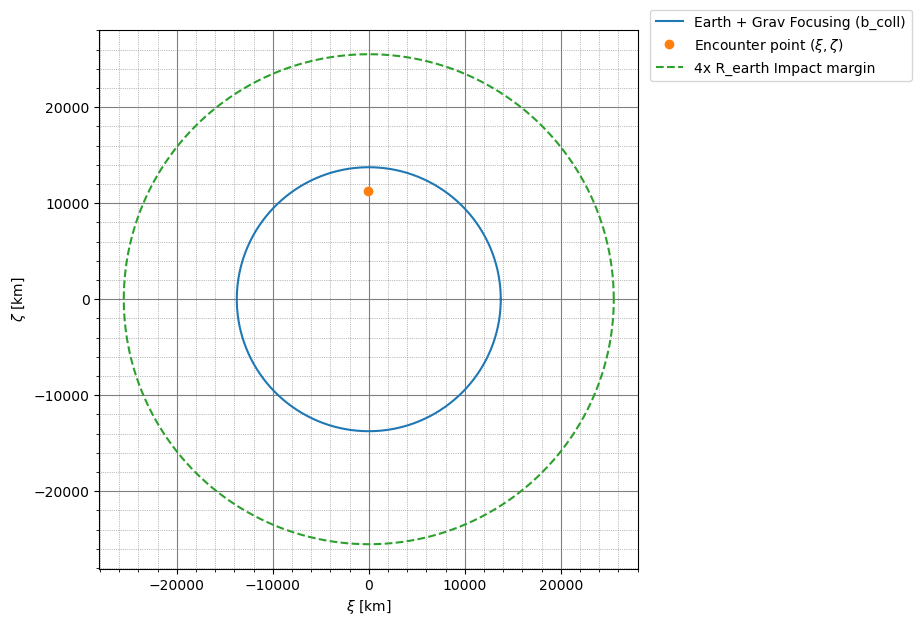

In [123]:
print(f"Distance from Earth [km]= {np.linalg.norm(r2_h_cont-r1_h):.3f}")
b_coll, xi, zeta = bplane(r1_h,v1_h, r2_h_cont, v2_h_cont)
plt_deadon = plot_bplane(b_coll,xi,zeta)
plt_deadon.savefig("p3_hw2.png",format='png',dpi=300)
plt.show()

### Problem 4: Kinetic impact

Also should work for a nuclear blast?

You can modify the Planetary Equations to work for a Kinetic Impact by transforming them from differential equations into difference equations and assume a quasi-instantaneous change in the orbital element